## Mosquito Abundance Predictions

This code uses the trained Aedes-AI model to generate abundance predictions for locations in Puerto Rico using mean temperature (C), precipitation (cm), and relative humidity (%) information in four neighborhoods in Puerto Rico. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys, os, json, importlib, glob, math
sys.path.append( os.path.abspath(os.path.join('..')) )
import utils.utils as gen_utils
from datetime import datetime, timedelta

from sklearn.preprocessing import MinMaxScaler
import utils.finetune_training as finetune
import utils.predictions as predictions
import utils.forecast as forecast

# Opening config file
f = open('../fpaths_config.json')
paths = json.load(f)

mols_path = paths["raw_mols"]
nn_preds_path = paths["nn_abundance_predictions"]
model_files_path = paths["model_files"]
comparison_path = paths["comparison_path"]


## Run ANN base model predictions

We now use the daily weather time series created for each location as input to the trained ANN. The resulting rpedictions are then scaled and compared to the corresponding trap data.

In the setup calls below,
* The file `../utils/predictions.py` is slightly modified from the `Aedes-AI` package
* The file `../utils/gru_avg_temp_scaler.save` was created when the network was trained. It contains the minima and maxima of the training data, which are used to normalize the input weather information

268/268 [==============================] - 3s 11ms/step


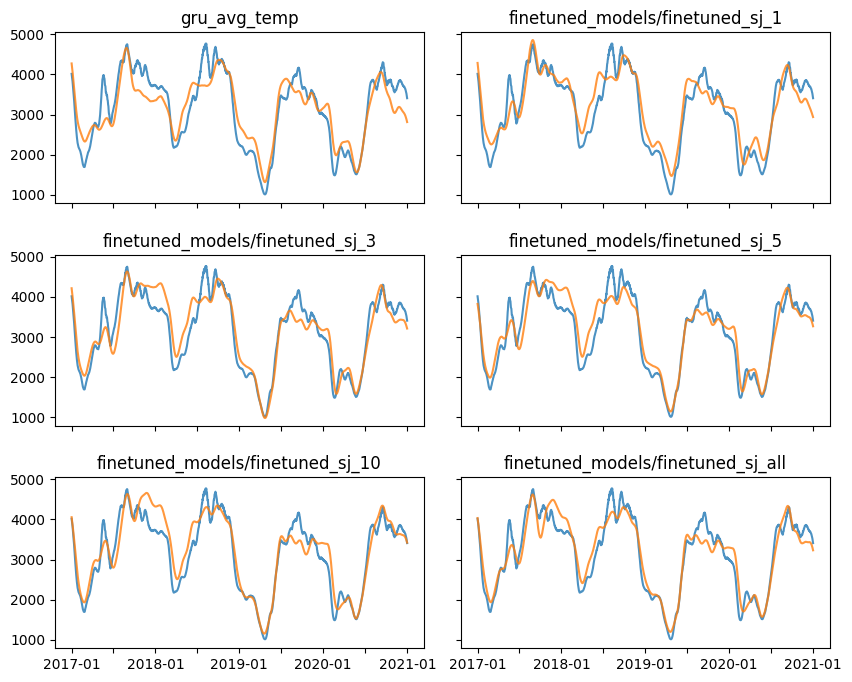

In [17]:
import tensorflow as tf
importlib.reload(gen_utils)
importlib.reload(forecast)

scaler = pd.read_pickle('{}/avg_scaler.pkl'.format(model_files_path))
#sj_scaler = pd.read_pickle('{}/sj_scaler.pkl'.format(model_files_path))

#model_fils = ['gru_avg_temp', 'finetuned_models/finetuned_noise_0', 'finetuned_models/finetuned_noise_1', 'finetuned_models/finetuned_noise_3',
#              'finetuned_models/finetuned_noise_5', 'finetuned_models/finetuned_noise_10']

model_fils = ['gru_avg_temp', 'finetuned_models/finetuned_sj_1', 'finetuned_models/finetuned_sj_3', 'finetuned_models/finetuned_sj_5',
              'finetuned_models/finetuned_sj_10', 'finetuned_models/finetuned_sj_all']

#noise = pd.read_csv('{}/finetune_noise_proxy.csv'.format(model_files_path))
data = pd.read_csv('../utils/model_files/finetune_sj.csv')

fig, axs = plt.subplots(3,2, figsize=(10,8), sharex=True, sharey=True)
axs = axs.ravel()

for model_fil,ax in zip(model_fils,axs):
    subset = data.copy()
    if (('finetuned' in model_fil) & (not 'all' in model_fil)):
        amt = int(model_fil.split('sj_')[-1])
                   
    model = tf.keras.models.load_model('{}/{}.h5'.format(model_files_path, model_fil), custom_objects={'r2_keras': predictions.r2_keras})

    X, y, locs = finetune.format_sj_mols(subset, scaler)
    results = finetune.gen_preds(model, X, y, locs, scaler)
    
    results = pd.DataFrame(results, columns=['Location', 'Year', 'Month', 'Day', 'Avg_Temp', 'Precip', 'Humidity', 'MoLS', 'Neural Network'])
    results['Datetime'] = pd.to_datetime(results[['Year', 'Month', 'Day']]) 

    #apply rolling average 
    results['Neural Network'] = forecast.moving_avg(results['Neural Network'], n=21, double=True)
    
    results = results[(results.Year>2016) & (results.Year<2021)].reset_index(drop=True)
    #results = results[results.Year>2016].reset_index(drop=True)
       
    ax.plot(results.Datetime, results['MoLS'], label='MoLS', color='tab:blue', alpha=0.8)
    ax.plot(results.Datetime, results['Neural Network'], label='Base NN', color='tab:orange', alpha=0.8)
    ax.set_title(model_fil)

    
    # Hide every other x tick label
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0:
            label.set_visible(False)
    
    results.to_csv('{}/{}_predictions.csv'.format(nn_preds_path, model_fil.split('finetuned_models/')[-1]), index=False)

plt.subplots_adjust(wspace=0.1, hspace=0.3)
#plt.savefig('{}/basemodel_predictions.png'.format(comparison_path), dpi=300, bbox_inches='tight')
plt.show()